___

<a href='http://www.pieriandata.com'><img src='../Pierian_Data_Logo.png'/></a>
___
<center><em>Copyright Pierian Data</em></center>
<center><em>For more information, visit us at <a href='http://www.pieriandata.com'>www.pieriandata.com</a></em></center>

# Forecast Evaluations

### Classic Train/Test Split

In [1]:
import pandas as pd
from prophet import Prophet
%matplotlib inline

Importing plotly failed. Interactive plots will not work.


In [2]:
df = pd.read_csv('../Data/Miles_Traveled.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588 entries, 0 to 587
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   DATE              588 non-null    object 
 1   TRFVOLUSM227NFWA  588 non-null    float64
dtypes: float64(1), object(1)
memory usage: 9.3+ KB


In [4]:
df.head()

,DATE,TRFVOLUSM227NFWA
0,1970-01-01,80173.0
1,1970-02-01,77442.0
2,1970-03-01,90223.0
3,1970-04-01,89956.0
4,1970-05-01,97972.0


In [5]:
df.columns = ['ds','y']

In [6]:
# YOU CAN SAFELY IGNORE THIS COPY WARNING
# CHECK THE DOCS LINK FOR MORE INFO ON THIS COPY WARNING
df['ds'] = pd.to_datetime(df['ds'])

In [7]:
df.head()

,ds,y
0,1970-01-01,80173.0
1,1970-02-01,77442.0
2,1970-03-01,90223.0
3,1970-04-01,89956.0
4,1970-05-01,97972.0


<Axes: xlabel='ds'>

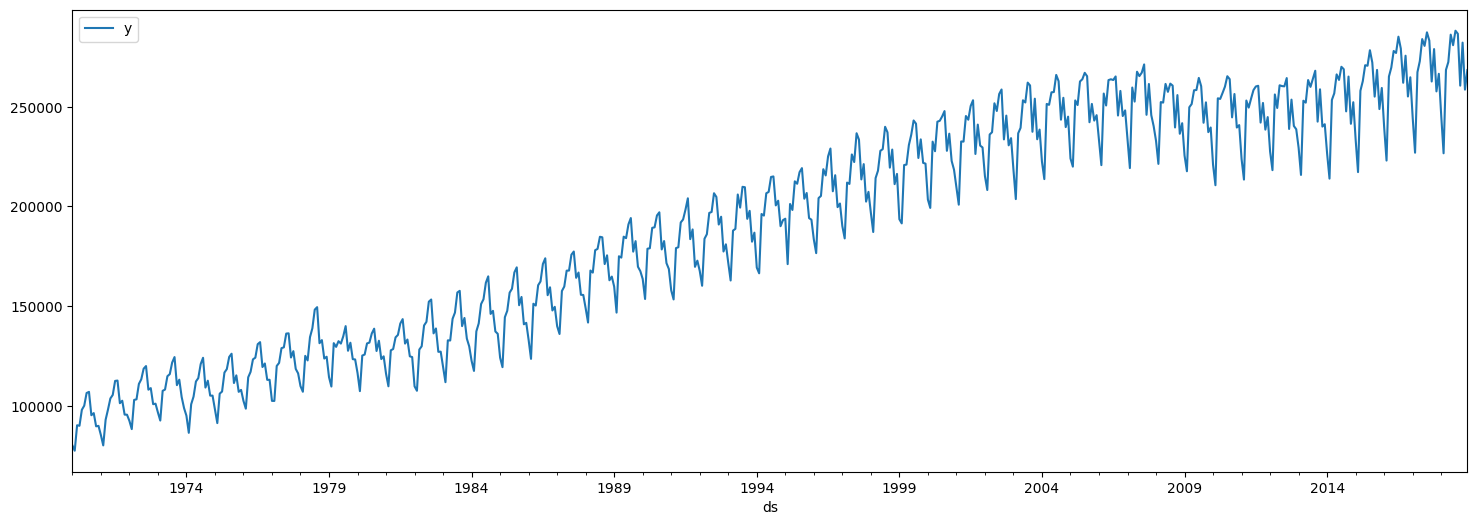

In [8]:
df.plot(x='ds',y='y',figsize=(18,6))

In [9]:
len(df)

588

In [10]:
len(df) - 12

576

In [12]:
train = df.iloc[:576]
test = df.iloc[576:]

In [13]:
m = Prophet()
m.fit(train)
future = m.make_future_dataframe(periods=12,freq='MS')
forecast = m.predict(future)

17:58:57 - cmdstanpy - INFO - Chain [1] start processing
17:58:57 - cmdstanpy - INFO - Chain [1] done processing


In [14]:
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
583,2018-08-01,263251.512327,274012.988882,286065.098593,263221.440352,263334.513155,16449.461969,16449.461969,16449.461969,16449.461969,16449.461969,16449.461969,0.0,0.0,0.0,279700.974296
584,2018-09-01,263390.235562,256617.540968,267540.238455,263330.386615,263503.111601,-1667.411743,-1667.411743,-1667.411743,-1667.411743,-1667.411743,-1667.411743,0.0,0.0,0.0,261722.823819
585,2018-10-01,263524.483855,263434.629561,274644.666530,263434.825265,263677.740810,5309.266513,5309.266513,5309.266513,5309.266513,5309.266513,5309.266513,0.0,0.0,0.0,268833.750368
586,2018-11-01,263663.207090,249679.800075,261029.336832,263538.369478,263859.206836,-8205.256748,-8205.256748,-8205.256748,-8205.256748,-8205.256748,-8205.256748,0.0,0.0,0.0,255457.950343
587,2018-12-01,263797.455383,251439.289818,262354.656360,263638.329565,264032.900142,-6918.099521,-6918.099521,-6918.099521,-6918.099521,-6918.099521,-6918.099521,0.0,0.0,0.0,256879.355861


In [15]:
test.tail()

,ds,y
583,2018-08-01,286608.0
584,2018-09-01,260595.0
585,2018-10-01,282174.0
586,2018-11-01,258590.0
587,2018-12-01,268413.0


[Info on ax= parameter](https://stackoverflow.com/questions/13872533/plot-different-dataframes-in-the-same-figure)

<Axes: xlabel='ds'>

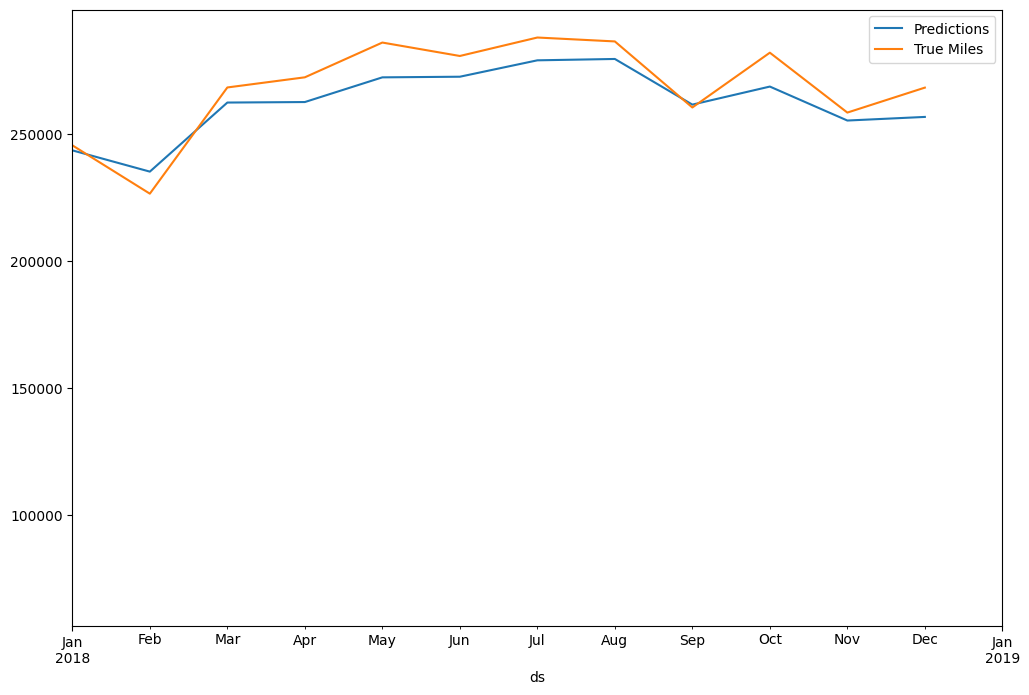

In [16]:
ax = forecast.plot(x='ds',y='yhat',label='Predictions',legend=True,figsize=(12,8))

test.plot(x='ds',y='y',label='True Miles',legend=True,ax=ax,xlim=('2018-01-01','2019-01-01'))

In [17]:
from statsmodels.tools.eval_measures import rmse

In [18]:
predictions = forecast.iloc[-12:]['yhat']

In [19]:
predictions

576    243712.120206
577    235338.959421
578    262538.761027
579    262738.354740
580    272460.074159
581    272709.370569
582    279166.704802
583    279700.974296
584    261722.823819
585    268833.750368
586    255457.950343
587    256879.355861
Name: yhat, dtype: float64

In [20]:
test['y']

576    245695.0
577    226660.0
578    268480.0
579    272475.0
580    286164.0
581    280877.0
582    288145.0
583    286608.0
584    260595.0
585    282174.0
586    258590.0
587    268413.0
Name: y, dtype: float64

In [21]:
rmse(predictions,test['y'])

8728.546089630176

In [22]:
test.mean()

ds    2018-06-16 12:00:00
y           268739.666667
dtype: object

# Prophet Diagnostics

Prophet includes functionality for time series cross validation to measure forecast error using historical data. This is done by selecting cutoff points in the history, and for each of them fitting the model using data only up to that cutoff point. We can then compare the forecasted values to the actual values.

In [23]:
from prophet.diagnostics import cross_validation,performance_metrics
from prophet.plot import plot_cross_validation_metric

In [25]:
#initial: how much historical data you use before starting the rolling-window cross-validation process.
#period: The time period between each cross-validation step
#horizon: how far into the future the model will predict at each step



In [24]:
len(df)

588

In [206]:
len(df)/12

49.0

The initial period should be long enough to capture all of the components of the model, in particular seasonalities and extra regressors: at least a year for yearly seasonality, at least a week for weekly seasonality, etc.

In [207]:
# help(pd.Timedelta)

In [26]:
# Initial 5 years training period
initial = 5 * 365
initial = str(initial) + ' days'
# Fold every 5 years
period = 5 * 365
period = str(period) + ' days'
# Forecast 1 year into the future
horizon = 365
horizon = str(horizon) + ' days'

In [27]:
df_cv = cross_validation(m, initial=initial, period=period, horizon = horizon)

  0%|          | 0/9 [00:00<?, ?it/s]

18:12:34 - cmdstanpy - INFO - Chain [1] start processing
18:12:34 - cmdstanpy - INFO - Chain [1] done processing
18:12:34 - cmdstanpy - INFO - Chain [1] start processing
18:12:34 - cmdstanpy - INFO - Chain [1] done processing
18:12:34 - cmdstanpy - INFO - Chain [1] start processing
18:12:34 - cmdstanpy - INFO - Chain [1] done processing
18:12:34 - cmdstanpy - INFO - Chain [1] start processing
18:12:34 - cmdstanpy - INFO - Chain [1] done processing
18:12:34 - cmdstanpy - INFO - Chain [1] start processing
18:12:35 - cmdstanpy - INFO - Chain [1] done processing
18:12:35 - cmdstanpy - INFO - Chain [1] start processing
18:12:35 - cmdstanpy - INFO - Chain [1] done processing
18:12:35 - cmdstanpy - INFO - Chain [1] start processing
18:12:35 - cmdstanpy - INFO - Chain [1] done processing
18:12:35 - cmdstanpy - INFO - Chain [1] start processing
18:12:35 - cmdstanpy - INFO - Chain [1] done processing
18:12:35 - cmdstanpy - INFO - Chain [1] start processing
18:12:35 - cmdstanpy - INFO - Chain [1]

In [28]:
df_cv.head()

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,1977-01-01,108479.055376,107008.699368,109768.717986,102445.0,1976-12-11
1,1977-02-01,102996.079255,101604.297216,104412.135845,102416.0,1976-12-11
2,1977-03-01,118973.286434,117544.301885,120318.866580,119960.0,1976-12-11
3,1977-04-01,120612.895423,119075.368820,122020.269023,121513.0,1976-12-11
4,1977-05-01,127882.995885,126401.598364,129299.692407,128884.0,1976-12-11


In [29]:
df_cv.tail()

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
103,2017-08-01,273347.468280,267873.035241,279109.880390,283184.0,2016-12-01
104,2017-09-01,255467.816618,249330.137202,261101.342117,262673.0,2016-12-01
105,2017-10-01,262573.232042,257202.713289,268332.193501,278937.0,2016-12-01
106,2017-11-01,249224.463376,243290.129650,254709.257194,257712.0,2016-12-01
107,2017-12-01,250471.609411,244768.170328,255981.427322,266535.0,2016-12-01


In [30]:
performance_metrics(df_cv)

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,52 days,2.434692e+07,4934.259940,4532.679757,0.027732,0.023405,0.027315,0.4
1,53 days,2.181384e+07,4670.529411,4262.126477,0.024938,0.023405,0.024642,0.4
2,54 days,1.841963e+07,4291.809720,3737.267635,0.020049,0.022442,0.019891,0.5
3,55 days,2.331938e+07,4829.014175,4262.361866,0.023142,0.023405,0.022893,0.4
4,57 days,2.115307e+07,4599.246861,4001.692218,0.021436,0.022442,0.021228,0.5
...,...,...,...,...,...,...,...,...
94,360 days,1.855483e+07,4307.531480,3781.145204,0.019733,0.019590,0.019742,0.5
95,361 days,1.766459e+07,4202.926724,3504.294862,0.018350,0.018921,0.018370,0.5
96,362 days,3.193714e+07,5651.295704,4428.471081,0.022143,0.024723,0.022043,0.4
97,364 days,3.027065e+07,5501.877115,4273.653936,0.021568,0.021851,0.021481,0.5


/Users/yingliu/Desktop/self-dev/time-series/notebooks/.venv/lib/python3.12/site-packages/prophet/plot.py:546: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/Users/yingliu/Desktop/self-dev/time-series/notebooks/.venv/lib/python3.12/site-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


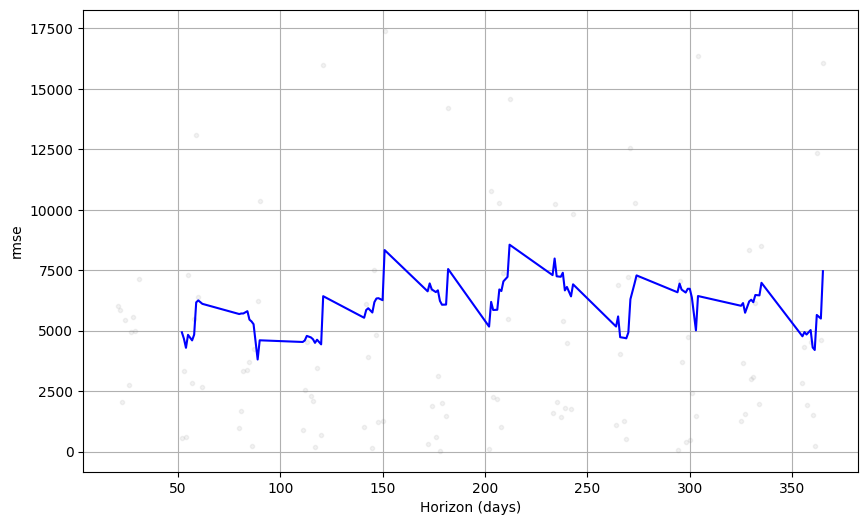

In [31]:
plot_cross_validation_metric(df_cv, metric='rmse');

MAPE is Mean Absolute Percentage Error

https://en.wikipedia.org/wiki/Mean_absolute_percentage_error

/Users/yingliu/Desktop/self-dev/time-series/notebooks/.venv/lib/python3.12/site-packages/prophet/plot.py:546: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/Users/yingliu/Desktop/self-dev/time-series/notebooks/.venv/lib/python3.12/site-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


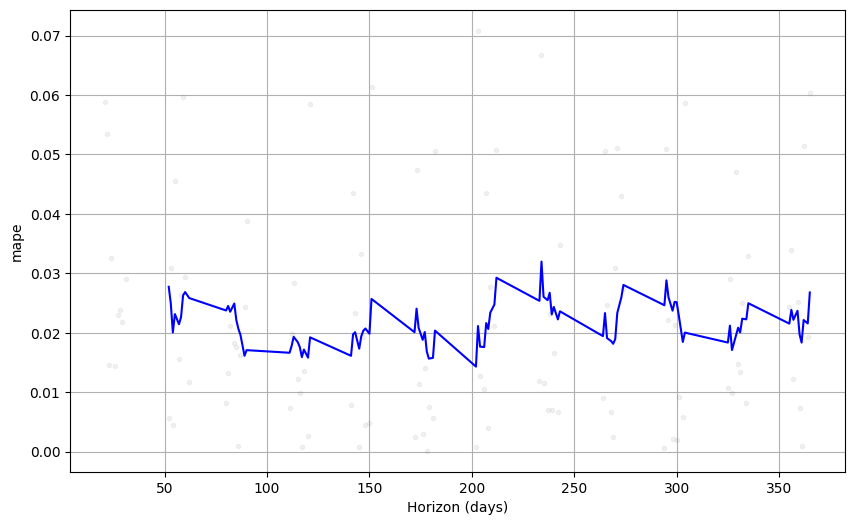

In [32]:
plot_cross_validation_metric(df_cv, metric='mape');

# Great Job!